# CMPU395 Final Project Analysis

Jensen Bergman and Jacob Sellitti - 5/1/26

## Introduction

Constructing an optimal batting order is a complex problem that blends player performance, team context, and strategic decision-making. In this notebook, we take a data-driven approach to this problem using Statcast data from the 2025 MLB season.

Our goal is to model how players are assigned lineup positions based on their offensive performance up to that point in the season. To do this, we implement a two-model framework:

- A player-level model that predicts the probability distribution over lineup positions (1–9) for an individual player
- A team-level model that predicts a full lineup for a group of nine players


In [4]:
# Install required packages
! pip install pandas numpy tqdm pybaseball scikit-learn torch

Defaulting to user installation because normal site-packages is not writeable


In [5]:
# Imports
import pandas as pd
from pybaseball import statcast, playerid_reverse_lookup
import csv
from io import StringIO
import datetime
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import ast
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from scipy.optimize import linear_sum_assignment
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Data Collection

Using the pybaseball library, we scraped pitch-by-pitch Statcast data for the 2025 MLB season. This dataset contains detailed information about every pitch, including outcomes (hits, strikeouts, walks), batted ball metrics (launch angle, exit velocity), and game context.

In addition, we incorporate lineup data scraped separately, which provides the batting order for each team in each game. This allows us to map individual player performances to their corresponding lineup positions.

The raw Statcast dataset is highly granular (one row per pitch), so a key challenge is transforming this into meaningful player-level features that evolve over the course of a season.


In [6]:
# LOAD STATCAST DATA FOR 2025 SEASON
season_2025 = statcast('2025-03-01', '2025-11-01')
# Only get regular season events where something happened (not just a ball or strike)
season_2025_events = season_2025[season_2025['events'].notna()]
season_2025_events = season_2025_events[season_2025_events['game_type'] == 'R']
# Filter by batters who had more than 100 total plate appearances
data = season_2025_events[season_2025_events['batter'].isin(
    season_2025_events['batter'].value_counts()[season_2025_events['batter'].value_counts() > 100].index)].copy()

# Convert MLB IDs to Retrosheet IDs for easier lineup merging
unique_players = data['batter'].dropna().unique().tolist()
player_map = playerid_reverse_lookup(unique_players)
player_map = player_map[['key_mlbam', 'key_retro']]
mlb_to_retro = dict(zip(player_map['key_mlbam'], player_map['key_retro']))
data['batter'] = data['batter'].map(mlb_to_retro)
data = data[data['batter'].notna()]

# Sort by date, team, and inning (assending)
season_2025_data = data.sort_values(by=['game_date', 'home_team', 'inning'])
print("Statcast data saved")

# LOAD GAME DATA TO PARSE BATTING ORDERS
with open('../data/gl2025.txt', 'r') as file:
    lines = file.readlines()
parsed = []
for line in lines:
    parsed.extend(list(csv.reader(StringIO(line))))

rows = []
for game in parsed:
    away_lineup = []
    home_lineup = []
    for i in range(9):
        away_lineup.append(game[105 + i*3])
        home_lineup.append(game[132 + i*3])
    date = datetime.datetime.strptime(game[0], '%Y%m%d').strftime('%Y-%m-%d')
    rows.append({
        'date': date,
        'away_lineup': away_lineup,
        'home_lineup': home_lineup
    })

lineups = pd.DataFrame(rows)
print("Lineup data saved")

This is a large query, it may take a moment to complete


/home/jsellitti/.local/lib/python3.10/site-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates


100%|██████████| 232/232 [04:01<00:00,  1.04s/it]


Gathering player lookup table. This may take a moment.
Statcast data saved
Lineup data saved


## Data Preparation and Feature Engineering

To construct meaningful inputs for our models, we aggregate pitch-level data into player-level statistics that reflect performance up to/before each game. This prevents data leakage and better reflects real-world decision-making.

For each player, we compute the following cumulative statistics:
- Batting Average (AVG) - Fraction of hits/at-bats of an individual player. This will be between 0 and 1.
- Slugging Percentage (SLG) - Fraction of total bases/at bats of an individual player, where singles are worth 1, doubles are worth 2, triples are worth 3, and home runs are worth 4. This will be between 0 and 4.
- On base percentage (OBP) - Fraction of times on base (hits + walks + hit by pitches) / plate appearances. Will be between 0 and 1.
- Expected weighted on-base average (xwOBA) - Measures offensive performance based on quality of contact (exit velocity and launch angle), removing the effect of defense and luck.
- Home Runs (HR) - Total number of home runs a batter has hit.
- Runs Batted In (RBI) - Total number of runs a batter has batted in.
- Stolen bases (SB) - Total number of stolen bases a player has.
- Contact percentage - Fraction of total contact (balls put in play) / total number of swings.
- Strikeout percentage (K%) - Fraction of strikeouts/total at-bats.
- Walk percentage (BB%) - Fraction of walks/total at-bats.
- Strikeout/Walk Ratio (K/BB) - Ratio of strikeouts to walks
- Sweet spot percentage - The percentage of the time a hitter hits a ball with a launch angle between 8 and 32 degrees.
- Hard hit percentage (HH%) - The percentage of the time a hitter hits a ball over 95 MPH.

We also implement safeguards such as:
- Safe division to avoid undefined values
- Filtering out early-season data (first 10 games) to allow statistics to stabilize
- Removing pinch hitters (players without consistent lineup positions) to ensure we have a max of 9 players per team per game

Finally, we join this data with lineup information to assign each player their batting order position for each game, and save the completed feature data.


In [ ]:
features_df = []

def get_lineup_pos(batter_id, lineups, side):
    for _, row in lineups.iterrows():
        lineup = row[side]
        if isinstance(lineup, str):
            lineup = ast.literal_eval(lineup)
        if batter_id in lineup:
            return lineup.index(batter_id) + 1
    return np.nan

for player_id, group in tqdm(season_2025_data.groupby('batter'), desc="Calculating features"):
    group = group.sort_values('game_date').copy()

    # Flag variables
    group['is_hit'] = group['events'].isin(['single', 'double', 'triple', 'home_run']).astype(int)
    group['is_ab'] = (~group['events'].isin(['walk', 'hit_by_pitch', 'sac_bunt', 'sac_fly'])).astype(int)
    group['is_bb'] = (group['events'] == 'walk').astype(int)
    group['is_k'] = (group['events'] == 'strikeout').astype(int)
    group['is_hr'] = (group['events'] == 'home_run').astype(int)
    group['is_hbp'] = (group['events'] == 'hit_by_pitch').astype(int)
    group['pa'] = group['is_ab'] + group['is_bb'] + group['is_hbp']
    group['is_bip'] = group['events'].isin(['single','double','triple','home_run',
                                            'field_out','force_out','grounded_into_double_play']).astype(int)
    group['tb'] = (
        (group['events'] == 'single').astype(int)
        + 2*(group['events'] == 'double').astype(int)
        + 3*(group['events'] == 'triple').astype(int)
        + 4*(group['events'] == 'home_run').astype(int)
    )

    # Cumulative stats up to that point
    c_hits = group['is_hit'].cumsum().shift(1).fillna(0)
    c_ab = group['is_ab'].cumsum().shift(1).fillna(0)
    c_tb = group['tb'].cumsum().shift(1).fillna(0)
    c_bb = group['is_bb'].cumsum().shift(1).fillna(0)
    c_k = group['is_k'].cumsum().shift(1).fillna(0)
    c_hbp = group['is_hbp'].cumsum().shift(1).fillna(0)
    c_pa = group['pa'].cumsum().shift(1).fillna(0)
    c_hr = group['is_hr'].cumsum().shift(1).fillna(0)
    c_bip = group['is_bip'].cumsum().shift(1).fillna(0)

    # Safe division helper
    def safe_div(num, denom):
        return np.where(denom > 0, num / denom, 0)

    group['AVG'] = safe_div(c_hits, c_ab)
    group['SLG'] = safe_div(c_tb, c_ab)
    group['OBP'] = safe_div(c_hits + c_bb + c_hbp, c_pa)
    group['HR'] = c_hr
    group['K%'] = safe_div(c_k, c_pa)
    group['BB%'] = safe_div(c_bb, c_pa)
    group['K/BB'] = safe_div(c_k, c_bb)
    group['Contact%'] = safe_div((c_pa - c_k), c_pa)
    group['sweet_spot'] = (group['launch_angle'].between(8, 32).fillna(False) & group['is_bip'].astype(bool)).astype(int)
    c_sweet = group['sweet_spot'].cumsum().shift(1).fillna(0)
    group['SweetSpot%'] = safe_div(c_sweet, c_bip)
    group['hard_hit'] = ((group['launch_speed'] >= 95).fillna(False) & group['is_bip'].astype(bool)).astype(int)
    c_hard = group['hard_hit'].cumsum().shift(1).fillna(0)
    group['HardHit%'] = safe_div(c_hard, c_bip)
    group['xwoba_est'] = (
        0.7*group['is_bb'] +
        0.9*(group['events'] == 'single').astype(int) +
        1.3*(group['events'] == 'double').astype(int) +
        1.6*(group['events'] == 'triple').astype(int) +
        2.0*(group['events'] == 'home_run').astype(int)
    )
    c_xwoba = group['xwoba_est'].cumsum().shift(1).fillna(0)
    group['xwOBA'] = safe_div(c_xwoba, c_pa)
    
    group['team'] = group['away_team'].where(group['inning_topbot'] == 'Top', group['home_team'])

    # Fetch lineup position
    group['lineup_pos'] = np.nan
    # Iterate through all games for that player
    for gdate in group['game_date'].unique():
        mask = group['game_date'] == gdate
        game_date_str = pd.to_datetime(gdate).strftime('%Y-%m-%d')
        batter_id = group.loc[mask, 'batter'].iloc[0]
        side = 'away_lineup' if group.loc[mask, 'inning_topbot'].iloc[0] == 'Top' else 'home_lineup'
        lineup_pos = get_lineup_pos(batter_id, lineups[lineups['date'] == game_date_str], side)
        group.loc[mask, 'lineup_pos'] = lineup_pos
    
    # Final features
    group = group[['game_date', 'batter', 'team', 'AVG', 'SLG', 'OBP', 'HR', 'xwOBA', 'K%', 'BB%', 'K/BB', 'Contact%', 'SweetSpot%', 'HardHit%', 'lineup_pos']]
    # Remove any rows where lineup_pos is not found - pinch hitters
    group = group[group['lineup_pos'].notna()]
    # Only keep one row per player per game
    group = group.groupby(['game_date', 'batter']).first().reset_index()
    # Drop first 10 games of season to allow for normalization of features
    group = group.iloc[10:]
    features_df.append(group)

features_df = pd.concat(features_df)
features_df.rename(columns={'batter': 'player_id'}, inplace=True)
features_df = features_df.sort_values(['game_date', 'team'])
print("Features saved to features_df")

Calculating features: 100%|██████████| 460/460 [00:45<00:00, 10.09it/s]

Features saved to features_df


In [12]:
print(features_df.head())

    game_date player_id team       AVG       SLG       OBP   HR     xwOBA  \
10 2025-04-05  crowp001  CHC  0.179487  0.256410  0.255814  0.0  0.223256   
10 2025-04-05  happi001  CHC  0.214286  0.309524  0.326531  1.0  0.295918   
10 2025-04-05  suzus001  CHC  0.255814  0.581395  0.333333  4.0  0.387500   
10 2025-04-05  swand001  CHC  0.205128  0.435897  0.279070  2.0  0.311628   
10 2025-04-05  tuckk001  CHC  0.300000  0.725000  0.428571  4.0  0.479592   

          K%       BB%      K/BB  Contact%  SweetSpot%  HardHit%  lineup_pos  
10  0.232558  0.069767  3.333333  0.767442    0.321429  0.392857         7.0  
10  0.224490  0.142857  1.571429  0.775510    0.300000  0.166667         1.0  
10  0.375000  0.104167  3.600000  0.625000    0.500000  0.541667         3.0  
10  0.186047  0.093023  2.000000  0.813953    0.413793  0.448276         5.0  
10  0.122449  0.183673  0.666667  0.877551    0.468750  0.437500         2.0  


## Dataset Construction

After feature engineering, we construct a dataset where each row represents a **player-game instance**, including:
- Player ID
- Team
- Game date
- Performance features
- Observed lineup position (target variable)

To ensure realistic evaluation, we split the data using a grouped train-test split, where all players from a single game are kept together. This prevents leakage between training and validation sets and ensures that full lineups are only seen in one split.

We also normalize features using standard scaling to improve model training stability.


In [10]:
feature_cols = [
    'AVG', 'SLG', 'OBP', 'HR', 'xwOBA',
    'K%', 'BB%', 'K/BB', 'Contact%', 'SweetSpot%', 'HardHit%'
]

X = features_df[feature_cols].values
y = features_df['lineup_pos'].astype(int).values
features_df['game_id'] = features_df['team'] + "_" + features_df['game_date'].astype(str)

# Create groups to ensure all 9 players from a single game stay together in the same split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=features_df['game_id']))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
val_df = features_df.iloc[val_idx].copy().reset_index(drop=True)

# feature normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

class PlayerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y - 1, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(PlayerDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(PlayerDataset(X_val, y_val), batch_size=32)


teams_df = features_df.groupby(['team', 'game_date']).filter(lambda g: len(g) == 9).copy()
teams_df['game_id'] = teams_df['team'] + "_" + teams_df['game_date'].astype(str)

train_game_ids = set(features_df.iloc[train_idx]['game_id'])
val_game_ids = set(features_df.iloc[val_idx]['game_id'])
train_teams_df = teams_df[teams_df['game_id'].isin(train_game_ids)]
val_teams_df = teams_df[teams_df['game_id'].isin(val_game_ids)]

class TeamDataset(Dataset):
    def __init__(self, teams_df):
        self.samples = []

        for _, group in teams_df.groupby(['team', 'game_date']):
            if len(group) != 9:
                continue

            group = group.sample(frac=1, random_state=42).reset_index(drop=True)
            features = scaler.transform(group[feature_cols].values)
            labels = group['lineup_pos'].values - 1
            player_ids = group['player_id'].values
            team = group['team'].iloc[0]
            game_date = group['game_date'].iloc[0]

            self.samples.append((features, labels, player_ids, team, game_date))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        X, y, pids, team, date = self.samples[idx]
        return (torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long),
            pids, team, date)

train_team_dataset = TeamDataset(train_teams_df)
val_team_dataset = TeamDataset(val_teams_df)

def team_collate_fn(batch):
    X, y, pids, teams, dates = zip(*batch)
    X = torch.stack(X)
    y = torch.stack(y)
    pids = list(pids)
    teams = list(teams)
    dates = list(dates)
    return X, y, pids, teams, dates

train_team_loader = DataLoader(train_team_dataset, batch_size=16,
                               shuffle=True, collate_fn=team_collate_fn)

val_team_loader = DataLoader(val_team_dataset, batch_size=16,
                             shuffle=False, collate_fn=team_collate_fn)

## Player-Level Model

We first train a neural network to predict lineup position for individual players.

This model takes in a vector of player performance features and outputs a probability distribution over the nine lineup positions using a softmax layer.

The architecture consists of:
- Two fully connected layers
- A learned embedding layer (32-dimensional representation)
- A final output layer with 9 logits

We train the model using categorical cross-entropy loss and the Adam optimizer, with L2 regularization to prevent overfitting. This model allows us to capture uncertainty in lineup placement, as players may occupy different positions throughout the season.

We evaluate the player model using several metrics:

- Top-1 Accuracy: Exact prediction of lineup position
- Top-3 Accuracy: Whether the true position is among the top 3 predicted probabilities
- Mean Absolute Error (MAE): Average positional distance between prediction and truth

Top-3 accuracy is particularly important, as lineup positions are ordinal and small errors (e.g., predicting 2 instead of 1) are less severe than larger ones. We also analyze prediction outputs and save them for further use in downstream modeling.

Training Player Model: 100%|██████████| 100/100 [01:37<00:00,  1.02it/s]


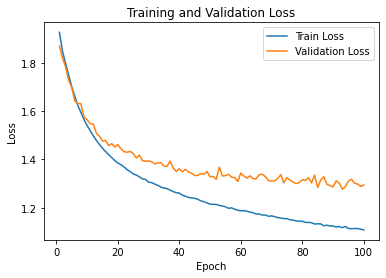

Player predictions saved to player_preds_df


In [15]:
# Player Model
class PlayerModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.embedding = nn.Linear(64, 32)
        self.out = nn.Linear(32, 9)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        emb = F.relu(self.embedding(x))
        logits = self.out(emb)
        return logits, emb

player_model = PlayerModel(X.shape[1])
optimizer = torch.optim.Adam(player_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 100
best_val_loss = float('inf')
epoch_losses = {}
best_state = None

for epoch in tqdm(range(num_epochs), desc="Training Player Model"):
    player_model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        logits, _ = player_model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    player_model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits, _ = player_model(X_batch)
            val_loss += criterion(logits, y_batch).item()

    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = player_model.state_dict()
    epoch_losses[epoch+1] = {
    'train_loss': train_loss,
    'val_loss': val_loss
}

# Plot training and validation loss
epochs = list(epoch_losses.keys())
train_losses = [epoch_losses[ep]['train_loss'] for ep in epochs]
val_losses = [epoch_losses[ep]['val_loss'] for ep in epochs]

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

player_model.load_state_dict(best_state)
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits, _ = player_model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.numpy())
        all_true.extend(y_batch.numpy())
        all_probs.extend(probs.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)
all_probs = np.array(all_probs)

player_top1 = np.mean(all_preds == all_true)
player_top3 = np.mean([
    all_true[i] in np.argsort(all_probs[i])[-3:]
    for i in range(len(all_true))
])
player_mae = np.mean(np.abs(all_preds - all_true))

all_preds_1to9 = all_preds + 1
all_true_1to9 = all_true + 1

player_preds_df = pd.DataFrame({
    "team": val_df['team'].values,
    "player_id": val_df['player_id'].values,
    "game_date": val_df['game_date'].astype(str).values,
    "predicted_lineup_pos": all_preds_1to9,
    "true_lineup_pos": all_true_1to9
})
print("Player predictions saved to player_preds_df")

In [20]:
print(player_preds_df.head())

  team player_id   game_date  predicted_lineup_pos  true_lineup_pos
0  LAD  edmat001  2025-04-06                     7                3
1  LAD  hernt002  2025-04-06                     9                4
2  LAD  ohtas001  2025-04-06                     1                1
3  LAD  pagea001  2025-04-06                     7                9
4  SEA  arozr001  2025-04-07                     6                3


## Team-Level Model

While the player model predicts positions independently, lineup construction is inherently a joint problem involving all nine players. To address this, we build a team-level model that takes all nine players in a lineup as input and predicts their positions simultaneously.

This model leverages the embeddings learned by the player model, using them as input features. By doing so, it captures richer representations of player skill while modeling interactions between players.

The model outputs a matrix of scores representing each player’s suitability for each lineup position.

To convert model outputs into a valid lineup (each position assigned exactly once), we apply the Hungarian algorithm (linear sum assignment). This ensures:
- Each player is assigned exactly one position
- Each lineup position is filled exactly once
- The overall assignment maximizes model confidence

We evaluate the team model using several metrics:
- Exact Match Accuracy: Percentage of perfectly predicted lineups
- Average Displacement: Average positional error across players
- Pairwise Accuracy: How often the model correctly predicts which player bats before another

We analyze position-specific accuracy and construct a confusion matrix to understand common prediction errors, and also use permutation importance to understand which features drive predictions.

In [21]:
# Team Model
class TeamModel(nn.Module):
    def __init__(self, player_model):
        super().__init__()
        self.player_model = player_model
        self.scorer = nn.Linear(32, 9)

    def forward(self, x):
        B, N, D = x.shape
        x = x.view(B * N, D)
        with torch.no_grad():
            _, emb = self.player_model(x)
        scores = self.scorer(emb)
        return scores.view(B, N, 9)

team_model = TeamModel(player_model)
optimizer = torch.optim.Adam(team_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in tqdm(range(num_epochs), desc="Training Team Model"):
    team_model.train()
    total_loss = 0

    for X_batch, y_batch, _, _, _ in train_team_loader:
        logits = team_model(X_batch)

        loss = 0
        for i in range(9):
            loss += criterion(logits[:, i, :], y_batch[:, i])
        loss /= 9

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

# Evaluate Team Model
exact_match = 0
displacements = []
pairwise_scores = []
lineup_results = []

for X_batch, y_batch, pids_batch, team_batch, date_batch in val_team_loader:
    with torch.no_grad():
        logits = team_model(X_batch)
        probs = torch.softmax(logits, dim=2).numpy()

    for b in range(len(X_batch)):
        cost = -probs[b]
        row_ind, col_ind = linear_sum_assignment(cost)

        pred = np.zeros(9, dtype=int)
        for r, c in zip(row_ind, col_ind):
            pred[r] = c

        true = y_batch[b].numpy()
        player_ids = list(pids_batch[b])
        true_lineup = [None] * 9
        for i, pos in enumerate(true):
            true_lineup[pos] = player_ids[i]
        pred_lineup = [None] * 9
        for player_idx, pos in enumerate(pred):
            pred_lineup[pos] = player_ids[player_idx]

        lineup_results.append({
            "team": team_batch[b],
            "game_date": str(date_batch[b]),
            "lineup": true_lineup,
            "predicted_lineup": pred_lineup
        })

        if np.array_equal(pred, true):
            exact_match += 1
        displacements.append(np.mean(np.abs(pred - true)))
        correct, total = 0, 0
        for i in range(9):
            for j in range(i+1, 9):
                total += 1
                if (pred[i] < pred[j]) == (true[i] < true[j]):
                    correct += 1
        pairwise_scores.append(correct / total)

team_exact = exact_match / len(val_team_dataset)
team_disp = np.mean(displacements)
team_pairwise = np.mean(pairwise_scores)

def evaluate_model(X, y):
    with torch.no_grad():
        logits, _ = player_model(torch.tensor(X, dtype=torch.float32))
        preds = torch.argmax(logits, dim=1).numpy()
    return mean_absolute_error(y, preds)
base_mae = evaluate_model(X_val, y_val)
importances = []
for i, col in enumerate(feature_cols):
    X_perm = X_val.copy()
    np.random.shuffle(X_perm[:, i])

    perm_mae = evaluate_model(X_perm, y_val)
    importance = perm_mae - base_mae
    importances.append((col, importance))
importances.sort(key=lambda x: x[1], reverse=True)

lineup_df = pd.DataFrame(lineup_results)
print("Predicted lineups saved to lineup_df\n")

output = f"""PLAYER MODEL:
Exact Accuracy: {player_top1:.4f}
Top-3 Accuracy (Actual position in top 3 predicted positions): {player_top3:.4f}
MAE: {player_mae:.4f}

TEAM MODEL:
Exact Match %: {team_exact:.4f}
Avg Displacement/Position Error: {team_disp:.4f}
Pairwise Accuracy (Predicting which player in each pair of 2 bats before the other): {team_pairwise:.4f}\n
Feature Importances:\n"""

for feat, imp in importances:
    output += f"{feat}: {imp:.4f}\n"
    
scores = {i: 0 for i in range(1, 10)}
for _, row in lineup_df.iterrows():
    pred_lineup = row['predicted_lineup']
    for pos in range(1, 10):
        if row['lineup'][pos-1] == pred_lineup[pos-1]:
            scores[pos] += 1
            
total_correct = sum(scores.values())
total_slots = 9 * len(lineup_df)
output += f"\nOverall Player Placement Accuracy: {total_correct}/{total_slots} ({(total_correct/total_slots)*100:.2f}%)\n"

output += "\nLineup Position Accuracy:\n"
for pos in range(1, 10):
    output += f"Position {pos}: {scores[pos] / len(lineup_df)*100:.2f}%\n"
    
conf_matrix = pd.DataFrame(0, index=range(1, 10), columns=range(1, 10))
for _, row in lineup_df.iterrows():
    pred_lineup = row['predicted_lineup']
    true_lineup = row['lineup']
    for true_pos in range(1, 10):
        true_player = true_lineup[true_pos-1]
        for pred_pos in range(1, 10):
            if pred_lineup[pred_pos-1] == true_player:
                conf_matrix.loc[true_pos, pred_pos] += 1
output += "\nConfusion Matrix: True Position (Rows) vs Predicted Position (Columns):\n"
output += str(conf_matrix)

Training Team Model: 100%|██████████| 100/100 [00:15<00:00,  6.62it/s]


Predicted lineups saved to lineup_df



In [22]:
print(lineup_df.head())

  team            game_date  \
0  ATH  2025-05-06 00:00:00   
1  ATH  2025-05-14 00:00:00   
2  ATH  2025-06-22 00:00:00   
3  ATH  2025-06-24 00:00:00   
4  ATH  2025-09-06 00:00:00   

                                              lineup  \
0  [butll001, rookb001, sodet001, andum001, langs...   
1  [wilsj006, sodet001, rookb001, langs001, butll...   
2  [butll001, wilsj006, rookb001, kurtn001, urial...   
3  [wilsj006, rookb001, kurtn001, wynna001, muncm...   
4  [langs001, rookb001, kurtn001, thomc005, wilsj...   

                                    predicted_lineup  
0  [wilsj006, urial001, sodet001, langs001, rookb...  
1  [butll001, sodet001, rookb001, langs001, andum...  
2  [butll001, wilsj006, rookb001, kurtn001, sodet...  
3  [butll001, wilsj006, rookb001, kurtn001, muncm...  
4  [butll001, langs001, rookb001, sodet001, wilsj...  


## Results, Insights, and Conclusions

Our results show that lineup position can be predicted with meaningful accuracy using player performance metrics.

Key observations include:
- Certain positions (e.g., beginning of the lineup) are easier to predict than others
- The model captures general lineup trends
- Joint modeling improves coherence of predicted lineups compared to independent predictions

However, performance is limited by factors not captured in the data, such as managerial preferences, injuries, and game-specific strategy. This work highlights both the potential and limitations of data-driven approaches to baseball strategy, and provides a foundation for future improvements incorporating additional context and data.



In [23]:
print(output)

PLAYER MODEL:
Exact Accuracy: 0.5238
Top-3 Accuracy (Actual position in top 3 predicted positions): 0.8450
MAE: 0.9201

TEAM MODEL:
Exact Match %: 0.1379
Avg Displacement/Position Error: 0.7435
Pairwise Accuracy (Predicting which player in each pair of 2 bats before the other): 0.8801

Feature Importances:
xwOBA: 0.7984
HardHit%: 0.6539
BB%: 0.6272
AVG: 0.5909
OBP: 0.5837
SLG: 0.5512
HR: 0.5397
SweetSpot%: 0.5254
K%: 0.4832
Contact%: 0.3569
K/BB: 0.3130

Overall Player Placement Accuracy: 2341/3852 (60.77%)

Lineup Position Accuracy:
Position 1: 85.28%
Position 2: 78.04%
Position 3: 73.13%
Position 4: 63.55%
Position 5: 48.13%
Position 6: 44.86%
Position 7: 40.89%
Position 8: 48.36%
Position 9: 64.72%

Confusion Matrix: True Position (Rows) vs Predicted Position (Columns):
     1    2    3    4    5    6    7    8    9
1  365   15    9    0   10   16    3    4    6
2   14  334   24   15   16   12    8    3    2
3    8   21  313   48   14   10    7    3    4
4    4   17   38  272   59  